**Notes to take into account**

Cuidado con openCV: lee en bgr (blue,green,red) -> si vamos a usar matplotlib para mostrar hay que convertir a rgb (cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

IMPORTANCIA de los *espacios de color*: ¿Cuándo usar cada espacio?
 - HSV: umbrales por tono (H) con luz cambiante; p. ej., detectar vegetación, flores por color.
 - Lab: análisis y comparación de color (ΔE), o segmentar con a* (verde↔rojo) y b* (azul↔amarillo).
 - YCrCb (YUV): separar luminancia (Y) de cromas (Cr/Cb); útil si hay parches de sombra/sol.
 - GRAY/BINARIA: bordes, texturas y máscaras para métricas (área, perímetro, cobertura).

Tener en cuenta el *suavizado*, sin pasarnos: GaussianBlur, MedianBlur. Más info en openCV documentation.

In [2]:
import os
import math
import json
import  cv2
import gc
import fiona
import rasterio
from scipy import stats
import openpyxl
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
from pathlib import Path
from rasterio import features
import scipy.stats as stats
import xml.etree.ElementTree as ET
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
from shapely.geometry import box
from rasterstats import zonal_stats
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, recall_score
from skimage.feature import graycomatrix, graycoprops
fiona.drvsupport.supported_drivers['KML'] = 'rw'
from rasterio.warp import calculate_default_transform, reproject, Resampling
from skimage.registration import phase_cross_correlation

**Paths and directories**

In [6]:
#BASE
path_base = "C:/Users/48755625H/Nextcloud/PhD ICA-CSIC/ESA_PP0106977"
#RASTER
ortho_path = Path(path_base) / "01_img_data/drone/DJI Matrice 300 RTK/2024-06-13_MaízPoveda_RGB_20m_Orthomosaic.tif"
raster_pln = Path(path_base) / "01_img_data/satellite/PlanetScope/20240613_111156_44_24fc_3B_AnalyticMS_SR_8b_harmonized_clip.tif"
img_final_pln = Path(path_base) / "01_img_data/satellite/PlanetScope/20240613_PlanetScope_clipped.tif"
ms_wv2_crudo = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001.TIF" 
pan_wv2_crudo = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-P3DS-050518203010_01_P001.TIF"
pansharp_esri = pan_wv2 = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_PAN_esri.TIF"
#SHAPEFILES
shp_path = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Polígonos.shp"
kml_aoi = "C:/Users/48755625H/Nextcloud/PhD ICA-CSIC/ESA_PP0106977/05_AOIs/AOI_LaPoveda.kml"
shp_path_EPSG32630 = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Polígonos_EPSG32630.shp"
shp_pln = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Patches_PlnScope_EPSG32630.shp"
shp_wv2 = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Patches_wv-02_EsquinaII_EPSG32630.shp"
shp_bounds = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024_bounds_Maiz-Sorgo_plot.shp"
shp_bounds_wv2 = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024_bounds_Maiz-Sorgo_plot_wv2.shp"
#XML
pln_xml = Path(path_base) /"01_img_data/satellite/PlanetScope/20240613_111156_44_24fc_3B_AnalyticMS_8b_metadata_clip.xml"
ms_wv2_xml = Path(path_base) /"00_downloads/EUSI-Vantor/26EUSI-0826-01-02-03 - 106977/050518203010_01/050518203010_01_P001_MUL/24JUN11104156-M3DS-050518203010_01_P001.XML"
pan_wv2_xml = Path(path_base) /"00_downloads/EUSI-Vantor/26EUSI-0826-01-02-03 - 106977/050518203010_01/050518203010_01_P001_PAN/24JUN11104156-P3DS-050518203010_01_P001.XML"
#PANSHARPENING
pansharp_BROV = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_simple_brovey.TIF"
pansharp_MEAN = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_simple_mean.TIF"
pansharp_ESRI = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_esri.TIF"
pansharp_GS = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_gram_schmidt.TIF"

out_pln = Path(path_base) / "01_img_data/satellite/PlanetScope/20240613_111156_44_24fc_3B_AnalyticMS_SR_8b_harmonized_BOA.tif"
out_pan_wv2 = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-P3DS-050518203010_01_P001_BOA.TIF"
out_ms_wv2 = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA.TIF"

Algunas imágenes satelitales (**EUSI-Vantor**) las hemos pedido en formato BUNDLE (Pancromática + Multiespectral) y no clip a la AOI específica. Las de **PlanetScope** vienen clipeadas a la zona, corregidas geometricamente, orhtorectificadas y tenemos la duda de si se les ha aplicado corrección atmosférica, además están harmonizadas a valores de Sentinel-2 (todo realizado por el equipo de planet).

**Dudas:**
- Planet no tiene PAN + MS, sino una imagen de 8 bandas. Para poder comparar con las imagenes en formato bundle, ¿debo hacerles el pan-sharpening previamente? comprometemos la integridad espectral de los datos (a tener en cuenta a la hora de calcular índices de vegetación), pero claro cuando se trata de análisis espacial es una opción a tener bastante en cuenta.
- Método seleccionado para pan-sharpening? https://github.com/ThomasWangWeiHong/Simple-Pansharpening-Algorithms

Aqui incluir una función que busque imagenes en un directorio con la función rglob y te saque características: platform-sensor, spatial and spectral resolution, CRS, dimensions, etc

In [4]:
def extract_raster_data(root_dir_path):
    root_path = Path(root_dir_path)
    extensions = ['*.tif', '*.tiff', '*.vrt']
    img_files = []
    for ext in extensions:
        img_files.extend(root_path.rglob(ext))
    if not img_files:
        print(f"No images in  directory: {root_path}")
        return pd.DataFrame()

    metadata_records = [] #save each image metadata

    for img_path in img_files:
        try:
            with rasterio.open(img_path) as src:
                parts = img_path.parts
                platform = "Desconocida"
                sensor = "Desconocido"
                
                if "01_img_data" in parts:
                    idx = parts.index("01_img_data")
                    if idx + 1 < len(parts):
                        platform = parts[idx + 1]
                    if idx + 2 < len(parts):
                        sensor = parts[idx + 2]
                
                # Extraer nombres de las bandas de los metadatos
                band_names = []
                for i in range(src.count):
                    name = src.descriptions[i]
                    if name:
                        band_names.append(name)
                    else:
                        band_names.append(f"Band_{i+1}")
                band_names_str = ", ".join(band_names)
                
                #Imagery characteristics dictionary
                record = {
                    "File": img_path.name,
                    "Plataform": platform,
                    "Sensor": sensor,
                    "Spatial res (m)": round(src.res[0], 4),
                    "Spectral res (bands)": src.count,
                    "Band names": band_names_str,
                    "CRS": str(src.crs) if src.crs else "No definido",
                    "Columns": src.width,
                    "Rows": src.height,
                    "Geographic bounds": f"L:{round(src.bounds.left,2)}, B:{round(src.bounds.bottom,2)}, R:{round(src.bounds.right,2)}, T:{round(src.bounds.top,2)}"
                }
                
                metadata_records.append(record)
                
        except Exception as e:
            print(f"File processing error {img_path.name}: {e}")
    df = pd.DataFrame(metadata_records)
    print("                METADATA FROM AVAILABLE RASTER DATA")
    print("="*80)
    
    # use "to_string()" para evitar que pandas trunque las columnas en la consola
    print(df.to_string(index=False))
    return df

df_img = extract_raster_data(Path(path_base) / "01_img_data")

                METADATA FROM AVAILABLE RASTER DATA
                                                             File Plataform              Sensor  Spatial res (m)  Spectral res (bands)                                                     Band names        CRS  Columns   Rows                                   Geographic bounds
   20240613_111156_44_24fc_3B_AnalyticMS_SR_8b_harmonized_BOA.tif satellite         PlanetScope           3.0000                     8 Band_1, Band_2, Band_3, Band_4, Band_5, Band_6, Band_7, Band_8 EPSG:32630     1778   1734    L:455775.0, B:4460595.0, R:461109.0, T:4465797.0
  20240613_111156_44_24fc_3B_AnalyticMS_SR_8b_harmonized_clip.tif satellite         PlanetScope           3.0000                     8  coastal_blue, blue, green_i, green, yellow, red, rededge, nir EPSG:32630     1778   1734    L:455775.0, B:4460595.0, R:461109.0, T:4465797.0
                                 20240613_PlanetScope_clipped.tif satellite         PlanetScope           3.0000     

**Debemos comprobar que las 3 imágenes hablan el mismo idioma, mismas unidades de reflectancia:**

- PlanetScope: Sus valores llegan hasta ~7000. Planet entrega sus imágenes en ND con un valor "reflectanceCoefficient". Este número convierte los Niveles Digitales (DN) directamente a Reflectancia TOA (Top of atmosphere) ya que en el xml viene indicado que las imágenes no han sufrido corrección atmosférica.   
- WorldView-2 (2.0m): Su máximo es exactamente 2047. Esto significa que está entregando Niveles Digitales (DN) crudos en 11-bits ($2^{11} = 2048$). No está calibrado a reflectancia. Necesitamos un archivo de texto que suele venir con la imagen original llamado .IMD (Image Metadata). En él vienen factores de calibración únicos del día que se tomó la imagen y tanto la pan como la MS tienen el suyo propio. Con dichos parámetros calculamos radiancia, reflentancia TOA y reflectancia BOA.
- Esta corrección debe ser un paso previo al pan-sharpening. 

In [5]:
def auditar_raster(ruta_raster, nombre_sensor):
    print(f"AUDITORÍA RADIOMÉTRICA: {nombre_sensor}")
    print("-" * 50)
    
    with rasterio.open(ruta_raster) as src:
        # Metadatos básicos
        print(f"1. Tipo de dato (dtype): {src.dtypes[0]}")
        print(f"2. Nodata definido:      {src.nodata}")
        print(f"3. Dimensiones:          {src.width} columnas x {src.height} filas")
        print(f"4. Bandas totales:       {src.count}")
        
        # Leemos la imagen reduciendo la resolución (1/10) para no saturar tu memoria RAM
        factor = 10
        out_shape = (src.count, int(src.height / factor), int(src.width / factor))
        
        # Leemos la banda 1 (Coastal/Blue) y la banda NIR (7 en WV2, 8 en Planet)
        b1 = src.read(1, out_shape=(out_shape[1], out_shape[2]))
        
        # El índice de la banda NIR depende del satélite (1-based en rasterio)
        idx_nir = 7 if src.count == 8 and 'WV2' in nombre_sensor else src.count
        bnir = src.read(idx_nir, out_shape=(out_shape[1], out_shape[2]))
        
        # Máscara para no incluir el nodata (fondo negro) en las estadísticas
        val_nodata = src.nodata if src.nodata is not None else 0
        b1_validos = b1[b1 != val_nodata]
        bnir_validos = bnir[bnir != val_nodata]
        
        if len(b1_validos) > 0:
            print("\nEstadísticas de la primera y última banda:")
            print(f"   Banda 1 (Azul): Min={b1_validos.min():.2f} | Max={b1_validos.max():.2f} | Media={b1_validos.mean():.2f}")
            print(f"   Banda Infrarroja: Min={bnir_validos.min():.2f} | Max={bnir_validos.max():.2f} | Media={bnir_validos.mean():.2f}")
        else:
            print("\n⚠️ ALERTA: No se encontraron píxeles válidos en la muestra.")
            
        print("=" * 60 + "\n")

# EJECUCIÓN: Reemplaza con tus variables de ruta
auditar_raster(ms_wv2_crudo, "WorldView-2 (2.0m)")
auditar_raster(raster_pln, "PlanetScope (3.0m)")

AUDITORÍA RADIOMÉTRICA: WorldView-2 (2.0m)
--------------------------------------------------
1. Tipo de dato (dtype): uint16
2. Nodata definido:      None
3. Dimensiones:          2483 columnas x 2797 filas
4. Bandas totales:       8

Estadísticas de la primera y última banda:
   Banda 1 (Azul): Min=318.00 | Max=1274.00 | Media=404.59
   Banda Infrarroja: Min=13.00 | Max=2047.00 | Media=665.14

AUDITORÍA RADIOMÉTRICA: PlanetScope (3.0m)
--------------------------------------------------
1. Tipo de dato (dtype): uint16
2. Nodata definido:      0.0
3. Dimensiones:          1778 columnas x 1734 filas
4. Bandas totales:       8

Estadísticas de la primera y última banda:
   Banda 1 (Azul): Min=28.00 | Max=5019.00 | Media=689.91
   Banda Infrarroja: Min=144.00 | Max=7063.00 | Media=2487.66



Los dos satélites deben estar en BOA. Nosotros obtenemos las imágenes en TOA de Planet y en números digitales de wv-2. Tenemos influencia de la atmósfera en los valores espectrales y además no tenemos valores de reflectancia en la imagen de wv-2.

In [6]:
'''
print("🌍 INICIANDO PIPELINE MULTI-SENSOR AUTOMATIZADO (WV2 & PLANET)")
print("=" * 75)

# =====================================================================
# 1. LECTOR XML INTELIGENTE (Con Verificación Visual)
# =====================================================================
def extraer_factores_xml(ruta_xml, sensor, es_multiespectral=True):
    print(f"\n📖 Leyendo metadatos ({sensor}): {os.path.basename(ruta_xml)}")
    tree = ET.parse(ruta_xml)
    root = tree.getroot()
    factores = {}
    
    print(f"\n🔍 VERIFICACIÓN VISUAL DE FACTORES EXTRAÍDOS ({sensor}):")
    print("-" * 95)
    
    if sensor.upper() == "WV2":
        # Constantes de Irradiancia Solar (Esun) de Maxar
        esun_wv2 = {1: 1758.22, 2: 1974.24, 3: 1845.99, 4: 1488.47,
                    5: 1038.06, 6: 1161.08, 7: 825.26, 8: 473.66}
        esun_pan = 1577.06
        
        # Extraer variables geométricas del momento de la captura
        try:
            sun_elev = float(root.find('.//MEANSUNEL').text)
            nodo_dist = root.find('.//EARTHSUNDISTANCE')
            earth_sun_dist = float(nodo_dist.text) if nodo_dist is not None else 1.0
            print(f"☀️  Elevación Solar: {sun_elev}° | Distancia Tierra-Sol: {earth_sun_dist} UA")
        except AttributeError:
            sun_elev, earth_sun_dist = 60.0, 1.0
            print("⚠️ No se encontró la geometría solar. Asumiendo valores por defecto.")

        factor_geometrico = (earth_sun_dist**2 * math.pi) / math.sin(math.radians(sun_elev))
        
        print("-" * 95)
        print(f"{'Banda':<8} | {'AbsCalFactor':<15} | {'EffBandwidth':<15} | {'Esun':<8} | {'Mult. Final (Reflectancia)':<25}")
        print("-" * 95)
        
        if es_multiespectral:
            mapa_bandas = {'BAND_C': 1, 'BAND_B': 2, 'BAND_G': 3, 'BAND_Y': 4,
                           'BAND_R': 5, 'BAND_RE': 6, 'BAND_N': 7, 'BAND_N2': 8}
            for etiqueta, num_banda in mapa_bandas.items():
                nodo = root.find(f'.//{etiqueta}')
                if nodo is not None:
                    abs_cal = float(nodo.find('.//ABSCALFACTOR').text)
                    eff_bw = float(nodo.find('.//EFFECTIVEBANDWIDTH').text)
                    
                    radiancia_mult = abs_cal / eff_bw
                    multiplicador_final = (radiancia_mult * factor_geometrico) / esun_wv2[num_banda]
                    
                    factores[num_banda] = {'multiplicador': multiplicador_final}
                    print(f"Banda {num_banda:<2} | {abs_cal:<15.6e} | {eff_bw:<15.6e} | {esun_wv2[num_banda]:<8} | {multiplicador_final:<25.6e}")
        else: # Pancromática
            nodo_pan = root.find('.//BAND_P')
            if nodo_pan is None: nodo_pan = root
            abs_cal = float(nodo_pan.find('.//ABSCALFACTOR').text)
            eff_bw = float(nodo_pan.find('.//EFFECTIVEBANDWIDTH').text)
            
            radiancia_mult = abs_cal / eff_bw
            multiplicador_final = (radiancia_mult * factor_geometrico) / esun_pan
            factores[1] = {'multiplicador': multiplicador_final}
            print(f"Banda PAN| {abs_cal:<15.6e} | {eff_bw:<15.6e} | {esun_pan:<8} | {multiplicador_final:<25.6e}")

    elif sensor.upper() == "PLANET":
        print(f"{'Banda':<8} | {'ReflectanceCoefficient (Multiplicador Directo)':<40}")
        print("-" * 95)
        for elem in root.iter():
            if 'bandSpecificMetadata' in elem.tag:
                band_num = refl_coeff = None
                for child in elem.iter():
                    if 'bandNumber' in child.tag: band_num = int(child.text)
                    elif 'reflectanceCoefficient' in child.tag: refl_coeff = float(child.text)
                
                if band_num is not None and refl_coeff is not None:
                    factores[band_num] = {'multiplicador': refl_coeff}
                    print(f"Banda {band_num:<2} | {refl_coeff:<40.6e}")
                    
    print("-" * 95)
    input("🛑 Revisa los valores arriba. Si todo cuadra, presiona ENTER para continuar (o Ctrl+C para cancelar)...")
    
    return factores


# =====================================================================
# 2. MOTOR DE CORRECCIÓN (DN -> TOA -> DOS BOA)
# =====================================================================
def procesar_imagen_automatica(ruta_tif, ruta_xml, ruta_out, sensor, es_multiespectral=True):
    # 1. Leer y verificar factores
    factores = extraer_factores_xml(ruta_xml, sensor, es_multiespectral)
    
    print(f"\n🚀 Procesando {sensor} | Archivo: {os.path.basename(ruta_tif)}")
    
    # 2. Procesar la imagen
    with rasterio.open(ruta_tif) as src:
        meta = src.meta.copy()
        meta.update(dtype=rasterio.float32, nodata=0.0)
        nodata_in = src.nodata if src.nodata is not None else 0
        
        with rasterio.open(ruta_out, 'w', **meta) as dst:
            for i in range(1, src.count + 1):
                if i in factores:
                    banda = src.read(i)
                    multiplicador = factores[i]['multiplicador']
                    mascara = (banda != nodata_in) & (banda > 0)
                    
                    # A. TOA
                    toa_fisica = np.where(mascara, banda.astype(np.float32) * multiplicador, 0.0)
                    
                    # B. BOA (DOS1)
                    if mascara.any():
                        objeto_oscuro = np.percentile(toa_fisica[mascara], 0.01)
                        banda_boa = np.where(mascara, np.clip(toa_fisica - objeto_oscuro, a_min=0.0001, a_max=None), 0.0)
                        dst.write(banda_boa.astype(np.float32), i)
                        print(f"  -> Banda {i:02d} procesada | Bruma restada: {objeto_oscuro:.4e} | OK")
                    else:
                        dst.write(toa_fisica, i)
                else:
                    print(f"  -> ⚠️ Banda {i} omitida (No se encontraron factores).")
                    
    print(f"🎉 Guardado en: {ruta_out}")


# =====================================================================
# 3. EJECUCIÓN 
# =====================================================================
if __name__ == "__main__":
    
    # Ejemplo:
    procesar_imagen_automatica(pan_wv2_crudo, pan_wv2_xml, out_pan_wv2, sensor="WV2", es_multiespectral=False)
'''

'\nprint("🌍 INICIANDO PIPELINE MULTI-SENSOR AUTOMATIZADO (WV2 & PLANET)")\nprint("=" * 75)\n\n# =====================================================================\n# 1. LECTOR XML INTELIGENTE (Con Verificación Visual)\n# =====================================================================\ndef extraer_factores_xml(ruta_xml, sensor, es_multiespectral=True):\n    print(f"\n📖 Leyendo metadatos ({sensor}): {os.path.basename(ruta_xml)}")\n    tree = ET.parse(ruta_xml)\n    root = tree.getroot()\n    factores = {}\n\n    print(f"\n🔍 VERIFICACIÓN VISUAL DE FACTORES EXTRAÍDOS ({sensor}):")\n    print("-" * 95)\n\n    if sensor.upper() == "WV2":\n        # Constantes de Irradiancia Solar (Esun) de Maxar\n        esun_wv2 = {1: 1758.22, 2: 1974.24, 3: 1845.99, 4: 1488.47,\n                    5: 1038.06, 6: 1161.08, 7: 825.26, 8: 473.66}\n        esun_pan = 1577.06\n\n        # Extraer variables geométricas del momento de la captura\n        try:\n            sun_elev = float(root.find(\'.//

**Procesamiento de shapefiles e imágenes**
- Cambio de CRS del shapefile al de las imágenes satelitales (EPSG:25830->EPSG:32630)
- Error de la paralelaje muy visible en las imágenes de Worldview-2 hacia el suroeste (5 metros apróx tanto en x como en y). 
- Necesitamos dos shp de rodales para que las imágenes sean comparables. Desplazamos polígonos para que reprsenten "la misma zona" en ambas imágenes.
- Necesario corregir geometrías inválidas de ciertos rodales?

In [5]:
# Puntos de la esquina inferior izquierda
x_II_dron = 458560.0316  
y_II_dron = 4462647.4689 
x_II_wv2 = 458553.989   
y_II_wv2 = 4462650.133  

# Puntos baliza
x_B_dron = 458822.553  
y_B_dron = 4462821.675 
x_B_wv2 = 458822.349   
y_B_wv2 = 4462827.171

In [7]:
def desplazar_y_retornar_rodales(x_origen, y_origen, x_destino, y_destino, ruta_entrada, ruta_salida):
    """
    Calcula el desfase entre dos puntos de referencia, desplaza un shapefile,
    lo guarda en disco y RETORNA el GeoDataFrame modificado.
    """
    
    # 1. Calcular los metros exactos de desfase
    dx = x_destino - x_origen
    dy = y_destino - y_origen
    
    print(f"Iniciando proceso de desplazamiento...")
    print(f" -> Vector de traslación calculado: X={dx:.3f} m, Y={dy:.3f} m")
    
    # 2. Cargar el shapefile
    print(" -> Cargando archivo original en memoria...")
    rodales = gpd.read_file(ruta_entrada)
    
    # 3. Aplicar el desplazamiento a las geometrías (en memoria)
    print(" -> Aplicando corrección geométrica...")
    rodales_corregidos = rodales.copy() 
    rodales_corregidos['geometry'] = rodales_corregidos.geometry.translate(xoff=dx, yoff=dy)
    
    # 4. Guardar el nuevo shapefile en el disco duro
    print(f" -> Guardando archivo corregido en disco:\n    {ruta_salida}")
    
    # SOLUCIÓN: Usamos to_file sin el parámetro crs. 
    # pyogrio mantendrá el EPSG:32630 automáticamente.
    rodales_corregidos.to_file(ruta_salida)
    
    print("✅ Proceso completado con éxito.\n")
    
    # 5. RETORNAR el objeto modificado
    return rodales_corregidos


gdf_wv2 = desplazar_y_retornar_rodales(
    x_origen = x_II_dron, 
    y_origen = y_II_dron,
    x_destino = x_II_wv2,
    y_destino = y_II_wv2,
    ruta_entrada = shp_bounds,
    ruta_salida = shp_bounds_wv2
)

Iniciando proceso de desplazamiento...
 -> Vector de traslación calculado: X=-6.043 m, Y=2.664 m
 -> Cargando archivo original en memoria...
 -> Aplicando corrección geométrica...
 -> Guardando archivo corregido en disco:
    C:\Users\48755625H\Nextcloud\PhD ICA-CSIC\ESA_PP0106977\06_QGIS\23-05-2024_QGis_MaízLaPoveda\2024_bounds_Maiz-Sorgo_plot_wv2.shp
✅ Proceso completado con éxito.



In [ ]:

def pansharpen(m, pan, method='esri'):
    """ 
    Pan-sharpening universal para N-bandas.
    Métodos disponibles: 'simple_brovey', 'simple_mean', 'esri', 'gram_schmidt'.
    """
    # 1. Autogenerar ruta de salida
    m_dir = os.path.dirname(m)
    m_name, m_ext = os.path.splitext(os.path.basename(m))
    psh = os.path.join(m_dir, f"{m_name}_PAN_{method}{m_ext}")
  
    # 2. Leer multiespectral (Lee TODAS las bandas automáticamente)
    with rasterio.open(m) as f:
        metadata_ms = f.profile
        img_ms = np.transpose(f.read(), [1, 2, 0]) # Carga todas las bandas
    
    # 3. Leer pancromática
    with rasterio.open(pan) as g:
        metadata_pan = g.profile
        img_pan = g.read(1)
    
    # 4. Redimensionar Multiespectral al tamaño de la PAN
    ms_to_pan_ratio = metadata_ms['transform'][0] / metadata_pan['transform'][0]
    rescaled_ms = cv2.resize(img_ms, dsize=None, fx=ms_to_pan_ratio, fy=ms_to_pan_ratio, 
                             interpolation=cv2.INTER_CUBIC).astype(metadata_ms['dtype'])

    # 5. Ajuste de dimensiones (por si difieren por 1 píxel en los bordes)
    if img_pan.shape[0] < rescaled_ms.shape[0]:
        rescaled_ms = rescaled_ms[: img_pan.shape[0], :, :]
    else:
        img_pan = img_pan[: rescaled_ms.shape[0], :]
        
    if img_pan.shape[1] < rescaled_ms.shape[1]:
        rescaled_ms = rescaled_ms[:, : img_pan.shape[1], :]
    else:
        img_pan = img_pan[:, : rescaled_ms.shape[1]]
  
    del img_ms; gc.collect()
  
    # 6. Crear matriz vacía para el resultado (con el total de bandas original)
    img_psh = np.zeros(rescaled_ms.shape, dtype=metadata_pan['dtype'])
    metadata_pan['height'] = rescaled_ms.shape[0]
    metadata_pan['width'] = rescaled_ms.shape[1]
    
    # ==========================================
    # 7. MÉTODOS DE PAN-SHARPENING (Aplicados a TODAS las bandas)
    # ==========================================
    
    # MÉTODO A: Brovey Simple
    if method == 'simple_brovey':
        all_in = np.sum(rescaled_ms, axis=2).astype(np.float32)
        safe_all_in = np.where(all_in == 0, 1, all_in)
        ratio = img_pan / safe_all_in
        
        for band in range(rescaled_ms.shape[2]):
            img_psh[:, :, band] = np.multiply(rescaled_ms[:, :, band], ratio)
            
    # MÉTODO B: Media Simple
    elif method == 'simple_mean':
        for band in range(rescaled_ms.shape[2]):
            img_psh[:, :, band] = 0.5 * (rescaled_ms[:, :, band] + img_pan)
            
    # MÉTODO C: ESRI
    elif method == 'esri':
        ADJ = img_pan.astype(np.float32) - rescaled_ms.mean(axis=2)
        for band in range(rescaled_ms.shape[2]):
            banda_calc = rescaled_ms[:, :, band] + ADJ
            banda_calc = np.clip(banda_calc, 0, 65535)
            img_psh[:, :, band] = banda_calc        
            
    # MÉTODO D: GRAM-SCHMIDT
    elif method == 'gram_schmidt':
        print("Aplicando método Gram-Schmidt...")
        
        # 1. Crear PAN simulada (Media de todas las bandas MS)
        sim_pan = np.mean(rescaled_ms, axis=2).astype(np.float32)
        
        # Máscara para ignorar los bordes negros (nodata) en el cálculo estadístico
        mask = sim_pan > 0
        
        if np.any(mask):
            # 2. Igualar el histograma de la PAN real a la simulada
            mean_sim = np.mean(sim_pan[mask])
            std_sim = np.std(sim_pan[mask])
            mean_pan = np.mean(img_pan[mask])
            std_pan = np.std(img_pan[mask])
            
            if std_pan == 0: std_pan = 1e-6 # Evitar división por cero
            
            # PAN ajustada estadísticamente
            pan_matched = (img_pan.astype(np.float32) - mean_pan) * (std_sim / std_pan) + mean_sim
            
            # 3. Calcular la inyección de detalles espaciales
            var_sim = std_sim ** 2
            if var_sim == 0: var_sim = 1e-6
            
            for band in range(rescaled_ms.shape[2]):
                band_data = rescaled_ms[:, :, band].astype(np.float32)
                
                # Covarianza manual entre la banda actual y la PAN simulada (más seguro para la RAM)
                mean_band = np.mean(band_data[mask])
                cov = np.mean((band_data[mask] - mean_band) * (sim_pan[mask] - mean_sim))
                
                # Peso de inyección para esta banda específica
                weight = cov / var_sim
                
                # Ecuación final de Gram-Schmidt: MS_nueva = MS_original + Peso * (PAN_ajustada - PAN_simulada)
                banda_calc = band_data + weight * (pan_matched - sim_pan)
                
                # Recortar y guardar
                banda_calc = np.clip(banda_calc, 0, 65535) # Ajustar límite superior si trabajas fuera de Int16
                img_psh[:, :, band] = banda_calc
        else:
            print("Advertencia: Imagen vacía en Gram-Schmidt.")
            img_psh = rescaled_ms

    else:
        print("Método no reconocido. Usa 'esri', 'simple_brovey', 'simple_mean' o 'gram_schmidt'.")
        return None
        
    del img_pan, rescaled_ms; gc.collect()
  
    # 8. Guardar archivo final
    metadata_pan['count'] = img_psh.shape[2]
    with rasterio.open(psh, 'w', **metadata_pan) as dst:
        dst.write(np.transpose(img_psh, [2, 0, 1]))
        
    print(f"Pan-sharpening guardado en: {psh}")
    return img_psh

# ==========================================
# EJECUCIÓN
# ==========================================
img_simple_brovey = pansharpen(out_ms_wv2, out_pan_wv2, method='simple_brovey')
img_simple_mean = pansharpen(out_ms_wv2, out_pan_wv2, method='simple_mean')
img_esri = pansharpen(out_ms_wv2, out_pan_wv2, method='esri')
img_gram_schmidt = pansharpen(out_ms_wv2, out_pan_wv2, method='gram_schmidt')

'''

'\n\ndef pansharpen(m, pan, method=\'esri\'):\n    """ \n    Pan-sharpening universal para N-bandas.\n    Métodos disponibles: \'simple_brovey\', \'simple_mean\', \'esri\', \'gram_schmidt\'.\n    """\n    # 1. Autogenerar ruta de salida\n    m_dir = os.path.dirname(m)\n    m_name, m_ext = os.path.splitext(os.path.basename(m))\n    psh = os.path.join(m_dir, f"{m_name}_PAN_{method}{m_ext}")\n\n    # 2. Leer multiespectral (Lee TODAS las bandas automáticamente)\n    with rasterio.open(m) as f:\n        metadata_ms = f.profile\n        img_ms = np.transpose(f.read(), [1, 2, 0]) # Carga todas las bandas\n\n    # 3. Leer pancromática\n    with rasterio.open(pan) as g:\n        metadata_pan = g.profile\n        img_pan = g.read(1)\n\n    # 4. Redimensionar Multiespectral al tamaño de la PAN\n    ms_to_pan_ratio = metadata_ms[\'transform\'][0] / metadata_pan[\'transform\'][0]\n    rescaled_ms = cv2.resize(img_ms, dsize=None, fx=ms_to_pan_ratio, fy=ms_to_pan_ratio, \n                           

**Clipping particular farm AOI to patches shapefile in satellite imagery tile**

Cargando vectores...
Comprobando límites del AOI...
-> Aplicando recorte (Clip)...
Guardando imagen final en: C:\Users\48755625H\Nextcloud\PhD ICA-CSIC\ESA_PP0106977\01_img_data\satellite\PlanetScope\20240613_PlanetScope_clipped.tif


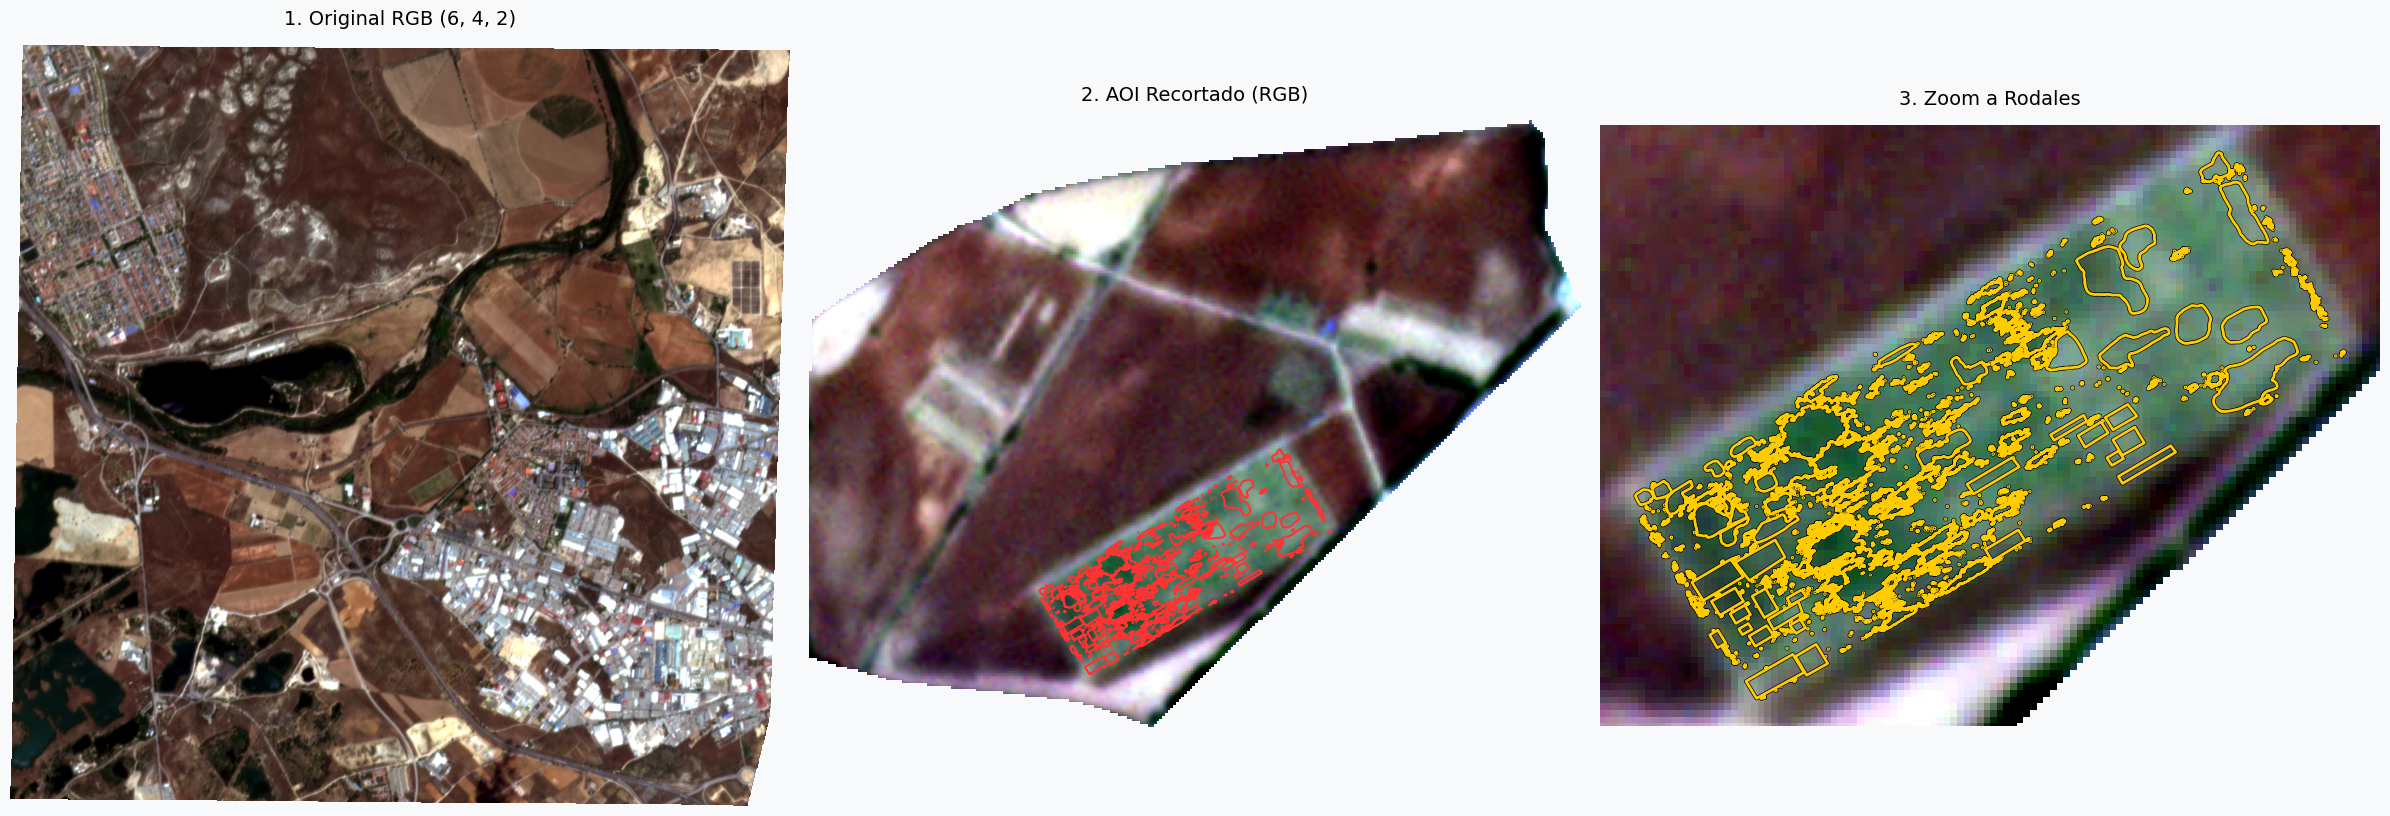

In [10]:
def optimizar_visualizacion(array, nodata_val=None):
    """
    Convierte el fondo negro en transparente y aplica un estiramiento
    de contraste (2% al 98%) para colores realistas y vibrantes.
    """
    # Convertir a float para soportar píxeles transparentes (NaN)
    array = array.astype(np.float32)
    
    # Identificar el fondo (normalmente 0 si no está definido el nodata)
    if nodata_val is None:
        nodata_val = 0
        
    fondo = (array == nodata_val)
    
    # Aplicar realce de contraste banda por banda
    for i in range(array.shape[0]):
        banda = array[i]
        # Calcular percentiles solo sobre los píxeles reales (ignorar fondo)
        pixeles_validos = banda[~fondo[i]]
        
        if len(pixeles_validos) > 0:
            p_min, p_max = np.percentile(pixeles_validos, (2, 98))
            # Estirar valores y normalizar entre 0 y 1 para Matplotlib
            banda = np.clip(banda, p_min, p_max)
            banda = (banda - p_min) / (p_max - p_min)
            array[i] = banda
            
    # Hacer el fondo transparente
    array[fondo] = np.nan
    
    return array


def procesar_y_visualizar_aoi(img_path, kml_path, path_shp, out_path):
    """
    1. Carga Raster, KML y Shapefile.
    2. Comprueba si necesita Clip. Si es así, recorta en memoria.
    3. Guarda el resultado final y lo visualiza (SE ELIMINÓ LA REPROYECCIÓN).
    """
    print("Cargando vectores...")
    shp_patches = gpd.read_file(path_shp)
    aoi_gdf = gpd.read_file(kml_path, driver="KML")
    
    with rasterio.open(img_path) as src:
        img_meta = src.meta.copy()
        img_crs = src.crs
        img_bounds = src.bounds
        
        # 2. COMPROBACIÓN DE RECORTE (CLIP)
        print("Comprobando límites del AOI...")
        aoi_img_crs = aoi_gdf.to_crs(img_crs)
        aoi_bounds = aoi_img_crs.total_bounds
        
        # Lógica: Si los bordes de la imagen superan el AOI (con 1 ud de tolerancia), hacemos clip
        necesita_clip = (img_bounds.left < aoi_bounds[0] - 1 or img_bounds.right > aoi_bounds[2] + 1 or
                         img_bounds.bottom < aoi_bounds[1] - 1 or img_bounds.top > aoi_bounds[3] + 1)
        
        if necesita_clip:
            print("-> Aplicando recorte (Clip)...")
            geom_aoi = [json.loads(aoi_img_crs.geometry.to_json())['features'][0]['geometry']]
            img_array, transform = mask(src, geom_aoi, crop=True)
            
            img_meta.update({
                "height": img_array.shape[1],
                "width": img_array.shape[2],
                "transform": transform
            })
        else:
            print("-> La imagen ya está ajustada al AOI. Omitiendo recorte...")
            img_array = src.read()
            # La variable transform ya está en img_meta

    # 3. GUARDAR RASTER DEFINITIVO
    print(f"Guardando imagen final en: {out_path}")
    # ¡Añadido el bloque de escritura que faltaba!
    with rasterio.open(out_path, "w", **img_meta) as dest:
        dest.write(img_array)

    # Adaptar temporalmente el CRS del shapefile al de la imagen solo para poder visualizarlo encima
    if shp_patches.crs != img_crs:
        shp_patches_vis = shp_patches.to_crs(img_crs)
    else:
        shp_patches_vis = shp_patches

    # ==========================================
    # 4. VISUALIZACIÓN MEJORADA
    # ==========================================
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.patch.set_facecolor('#f8f9fa') # Fondo general ligeramente gris/crema para destacar la imagen
    
    # --- PANEL 1: Imagen Original ---
    with rasterio.open(img_path) as orig_src:
        try:
            arr_orig = orig_src.read((6, 4, 2))
            titulo_1 = "1. Original RGB (6, 4, 2)"
        except IndexError:
            arr_orig = orig_src.read((3, 2, 1))
            titulo_1 = "1. Original RGB (3, 2, 1)"
            
        arr_orig_opt = optimizar_visualizacion(arr_orig, orig_src.nodata)
        show(arr_orig_opt, transform=orig_src.transform, ax=axes[0])
        axes[0].set_title(titulo_1, fontsize=14, pad=15)

    # --- PANELES 2 y 3: Imagen Procesada (Clip) ---
    with rasterio.open(out_path) as final_src:
        try:
            arr_final = final_src.read((6, 4, 2))
            titulo_2_3 = "RGB"
        except IndexError:
            arr_final = final_src.read((3, 2, 1))
            titulo_2_3 = "Other bands"
            
        arr_final_opt = optimizar_visualizacion(arr_final, final_src.nodata)
        
        # PANEL 2: Vista completa del Clip
        show(arr_final_opt, transform=final_src.transform, ax=axes[1])
        shp_patches_vis.plot(ax=axes[1], facecolor='none', edgecolor='#ff3333', linewidth=1.5)
        axes[1].set_title(f"2. AOI Recortado ({titulo_2_3})", fontsize=14, pad=15)
        
        # PANEL 3: Zoom al Bounding Box del Shapefile
        show(arr_final_opt, transform=final_src.transform, ax=axes[2])
        # Borde amarillo más brillante con un ligero efecto de sombra (borde negro por debajo)
        shp_patches_vis.plot(ax=axes[2], facecolor='none', edgecolor='black', linewidth=3)
        shp_patches_vis.plot(ax=axes[2], facecolor='none', edgecolor='#ffcc00', linewidth=2)
        axes[2].set_title("3. Zoom a Rodales", fontsize=14, pad=15)
        
        # Aplicar el Zoom
        minx, miny, maxx, maxy = shp_patches_vis.total_bounds
        margen_x = (maxx - minx) * 0.05
        margen_y = (maxy - miny) * 0.05
        axes[2].set_xlim(minx - margen_x, maxx + margen_x)
        axes[2].set_ylim(miny - margen_y, maxy + margen_y)

    # Ocultar los ejes numéricos para un acabado más estético y limpio
    for ax in axes:
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

    return out_path

# ==========================================
# EJECUCIÓN
# ==========================================
if __name__ == "__main__":
    procesar_y_visualizar_aoi(out_pln, kml_aoi, shp_path_EPSG32630, img_final_pln)
    pass

In [11]:
'''

def comparar_pansharpening_rapido(ruta_ms, metodos, path_shp):
    """
    Versión ultra-rápida. Utiliza Windowed Reading para cargar a RAM
    únicamente el trozo de imagen que coincide con los rodales.
    """
    print("Preparando comparativa visual (Modo Rápido)...")
    
    shp_patches = gpd.read_file(path_shp)
    
    m_dir = os.path.dirname(ruta_ms)
    m_name, m_ext = os.path.splitext(os.path.basename(ruta_ms))
    
    rutas_imagenes = [ruta_ms]
    titulos = ["Multiespectral Original (RGB)"]
    for metodo in metodos:
        rutas_imagenes.append(os.path.join(m_dir, f"{m_name}_PAN_{metodo}{m_ext}"))
        titulos.append(f"Pan-sharpening: {metodo.upper()}")

    num_imagenes = len(rutas_imagenes)
    filas = (num_imagenes + 1) // 2 
    fig, axes = plt.subplots(filas, 2, figsize=(20, 10 * filas))
    fig.patch.set_facecolor('#f8f9fa')
    
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, (ruta, titulo) in enumerate(zip(rutas_imagenes, titulos)):
        ax = axes[i]
        
        try:
            with rasterio.open(ruta) as src:
                # 1. Adaptar CRS si es necesario
                if i == 0 and shp_patches.crs != src.crs:
                    shp_vis = shp_patches.to_crs(src.crs)
                else:
                    shp_vis = shp_patches
                
                # 2. Calcular los límites espaciales PRIMERO
                minx, miny, maxx, maxy = shp_vis.total_bounds
                margen_x = (maxx - minx) * 0.1
                margen_y = (maxy - miny) * 0.1
                bbox_con_margen = (minx - margen_x, miny - margen_y, maxx + margen_x, maxy + margen_y)
                
                # 3. CREAR LA VENTANA (El truco para la velocidad)
                ventana = from_bounds(*bbox_con_margen, transform=src.transform)
                
                # 4. Leer SOLO esa ventana
                try:
                    arr = src.read((5, 3, 2), window=ventana)
                    band_str = "(6, 4, 2)"
                except IndexError:
                    arr = src.read((3, 2, 1), window=ventana)
                    band_str = "(3, 2, 1)"
                    
                # Calcular la nueva transformación espacial para ese trocito
                transform_ventana = src.window_transform(ventana)
                
                # 5. Optimizar y dibujar (ahora tarda milisegundos porque el array es enano)
                # Asegúrate de tener definida tu función optimizar_visualizacion() en tu código
                arr_opt = optimizar_visualizacion(arr, src.nodata)
                show(arr_opt, transform=transform_ventana, ax=ax)
                
                shp_vis.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=3)
                shp_vis.plot(ax=ax, facecolor='none', edgecolor='#ffcc00', linewidth=2)
                
                ax.set_title(f"{titulo}", fontsize=16, pad=15, fontweight='bold')
                ax.set_axis_off()
                
        except Exception as e:
            print(f"Error procesando {ruta}: {e}")
            ax.set_axis_off()

    for j in range(i + 1, len(axes)):
        axes[j].set_axis_off()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Sustituimos 'esri' por 'gram_schmidt' en la lista de métodos a visualizar
    metodos_procesados = ['simple_brovey', 'simple_mean', 'gram_schmidt']
    comparar_pansharpening_rapido(out_ms_wv2, metodos_procesados, shp_wv2)

'''

'\n\ndef comparar_pansharpening_rapido(ruta_ms, metodos, path_shp):\n    """\n    Versión ultra-rápida. Utiliza Windowed Reading para cargar a RAM\n    únicamente el trozo de imagen que coincide con los rodales.\n    """\n    print("Preparando comparativa visual (Modo Rápido)...")\n\n    shp_patches = gpd.read_file(path_shp)\n\n    m_dir = os.path.dirname(ruta_ms)\n    m_name, m_ext = os.path.splitext(os.path.basename(ruta_ms))\n\n    rutas_imagenes = [ruta_ms]\n    titulos = ["Multiespectral Original (RGB)"]\n    for metodo in metodos:\n        rutas_imagenes.append(os.path.join(m_dir, f"{m_name}_PAN_{metodo}{m_ext}"))\n        titulos.append(f"Pan-sharpening: {metodo.upper()}")\n\n    num_imagenes = len(rutas_imagenes)\n    filas = (num_imagenes + 1) // 2 \n    fig, axes = plt.subplots(filas, 2, figsize=(20, 10 * filas))\n    fig.patch.set_facecolor(\'#f8f9fa\')\n\n    if isinstance(axes, np.ndarray):\n        axes = axes.flatten()\n    else:\n        axes = [axes]\n\n    for i, (rut

Cargamos shapefile de rodales *Sorghum Halepense* (CRS cambiado a EPSG:32630) etiquetado según tamaño (alto, medio, bajo y no-sorgo) y calculamos valor espectral medio de cada objeto

In [12]:
def extraer_firmas(ruta_shp, ruta_raster, prefijo, col_id='ID_patch', col_lbl='Patch_size'):
    """
    Extrae las firmas espectrales considerando TODOS los píxeles que toque el rodal
    (all_touched=True) para evitar la pérdida de píxeles periféricos.
    """
    print(f"[{prefijo}] Extrayendo firmas espectrales (all_touched=True)...")
    gdf = gpd.read_file(ruta_shp)
    df = gdf[[col_id, col_lbl, 'Area_m2']].copy()
    
    with rasterio.open(ruta_raster) as src:
        nodata = src.nodata if src.nodata is not None else 0
        datos = []
        
        for geom in gdf.geometry:
            try:
                # 🚨 CAMBIO CLAVE: all_touched=True captura todo píxel que toque el polígono
                out, _ = mask(src, [geom], crop=True, all_touched=True)
                m = np.ma.masked_equal(out, nodata)
                media = m.mean(axis=(1, 2))
                datos.append(media.filled(np.nan) if np.ma.is_masked(media) else media)
            except ValueError:
                datos.append(np.full(src.count, np.nan))
                
    # Asignación vectorizada de columnas espectrales
    datos = np.array(datos)
    for i in range(datos.shape[1]):
        df[f'{prefijo}_B{i+1}'] = datos[:, i]
        
    return df

def calcular_indices(df, prefijo, b_nir, b_red, b_rededge=None):
    """Calcula NDVI y NDRE dinámicamente según las bandas del sensor."""
    df[f'{prefijo}_NDVI'] = (df[f'{prefijo}_B{b_nir}'] - df[f'{prefijo}_B{b_red}']) / (df[f'{prefijo}_B{b_nir}'] + df[f'{prefijo}_B{b_red}'])
    if b_rededge:
        df[f'{prefijo}_NDRE'] = (df[f'{prefijo}_B{b_nir}'] - df[f'{prefijo}_B{b_rededge}']) / (df[f'{prefijo}_B{b_nir}'] + df[f'{prefijo}_B{b_rededge}'])
    return df

# =====================================================================
# 2. PROCESAMIENTO INDEPENDIENTE DE LOS 3 DATASETS TARGET
# =====================================================================

COL_ID, COL_LBL = 'ID_patch', 'Patch_size'

# --- DATASET 1: PlanetScope (3m) ---
df_planet = extraer_firmas(shp_pln, out_pln, "PS_3m", COL_ID, COL_LBL)
df_planet = calcular_indices(df_planet, "PS_3m", b_nir=8, b_red=6, b_rededge=7) # Planet: B8=NIR, B6=Red, B7=RedEdge
df_planet_limpio = df_planet.dropna().reset_index(drop=True)

# --- DATASET 2: WorldView-2 MS Original (2m) ---
df_wv2_2m = extraer_firmas(shp_wv2, out_ms_wv2, "WV2_2m", COL_ID, COL_LBL)
df_wv2_2m = calcular_indices(df_wv2_2m, "WV2_2m", b_nir=7, b_red=5, b_rededge=6) # WV2: B7=NIR1, B5=Red, B6=RedEdge
df_wv2_2m_limpio = df_wv2_2m.dropna().reset_index(drop=True)

# --- DATASET 3: WorldView-2 Pansharpened GS (0.5m) ---
df_wv2_gs = extraer_firmas(shp_wv2, pansharp_GS, "WV2_05m_GS", COL_ID, COL_LBL)
df_wv2_gs = calcular_indices(df_wv2_gs, "WV2_05m_GS", b_nir=7, b_red=5, b_rededge=6) # Mismas bandas que WV2 original
df_wv2_gs_limpio = df_wv2_gs.dropna().reset_index(drop=True)

# =====================================================================
# 3. REPORTE AUTÓNOMO Y GUARDADO DE ARCHIVOS
# =====================================================================
print("\n" + "="*60)
print(" 📊 REPORTE DE EXTRACCIÓN INDEPENDIENTE (all_touched=True)")
print("="*60)
print(f"1. PlanetScope (3m)              -> Rodales válidos: {len(df_planet_limpio)}")
print(f"2. WorldView-2 MS (2m)           -> Rodales válidos: {len(df_wv2_2m_limpio)}")
print(f"3. WorldView-2 Pansharp GS (0.5m)-> Rodales válidos: {len(df_wv2_gs_limpio)}")
print("="*60 + "\n")

# Configurar rutas de almacenamiento
ruta_salida = Path(path_base) / "07_datasets"
ruta_salida.mkdir(parents=True, exist_ok=True)

# Guardar los 3 archivos físicos independientes en Excel
df_planet_limpio.to_excel(ruta_salida / "Dataset_1_Planet_3m.xlsx", index=False)
df_wv2_2m_limpio.to_excel(ruta_salida / "Dataset_2_WV2_MS_2m.xlsx", index=False)
df_wv2_gs_limpio.to_excel(ruta_salida / "Dataset_3_WV2_Pansharp_GS_05m.xlsx", index=False)

print("✅ ¡Éxito! Los 3 datasets independientes han sido exportados correctamente.")

[PS_3m] Extrayendo firmas espectrales (all_touched=True)...
[WV2_2m] Extrayendo firmas espectrales (all_touched=True)...
[WV2_05m_GS] Extrayendo firmas espectrales (all_touched=True)...

 📊 REPORTE DE EXTRACCIÓN INDEPENDIENTE (all_touched=True)
1. PlanetScope (3m)              -> Rodales válidos: 1881
2. WorldView-2 MS (2m)           -> Rodales válidos: 1881
3. WorldView-2 Pansharp GS (0.5m)-> Rodales válidos: 1881

✅ ¡Éxito! Los 3 datasets independientes han sido exportados correctamente.
